# PSTAT 100 Data Science Concepts and Analysis

## Assignment 3

**Author:** Chloe Lo Papa
**Date:** May 24th

---

#### Submission Instructions

This assignment will be **due for submission on Wednesday May 27th at 11:59PM**.  Please ensure you submit a `.pdf` file to Canvas by the posted time, no other file types will be accepted.  Please see the course website for some information regarding exporting Jupyter notebooks to pdf, and if you are having exporting problems discuss them with a member of the teaching staff in their office hours.

___

#### Collaboration

You are encouraged to work on your assignments independently.  Please only collaborate with others should you require assistance with more challenging problems. Should you need to collaborate with others, please note their names here:

> **Collaborators:**
___

#### Agent Usage

Additionally, you are permitted to use resources such as ChatGPT and Claude to help you with your homework assignments and to enhance your learning experience. Please make a note of any agents you have used in this submission here:

> **Agents:** 

**WARNING:** Please ensure you check and understand the outputs these agents produce.  Should your solution show evidence of abuse of AI usage (i.e. use external data not detailed in this assignment, use methods not covered in class) your solution will receive a score of 0.

---

## 1. Introduction

In this report we will be performing a statistical analysis to investigate the effect of economic, demographic and health factors on human life expectancy across various countries.  Our study will be utilizing the [Life Expectancy (WHO)](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who?resource=download) data, made available on Kaggle by Kumar Rajarshi and originally collected from WHO and United Nations website with the help of Deeksha Russell and Duan Wang.

In this project we consider data from year 2000-2015 for 193 countries for further analysis.  This will involve:

- **Data Preparation:**
    - Data Importing
    - Missingness.
    - Data Transformations.
- **Exploratory Data Analysis:**
    - Summary Statistic Tables
    - Univariate Distributions
    - Bivariate Relationships
- **Modelling:**
    - Fit a Simple Linear Regression (SLR) model. 
    - Fit several Multiple Linear Regression (MLR) models.
    - Evaluate model performance.
    - Residual analysis.

In this report we will be making use of the following libraries:

In [1]:
# Libraries
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import probplot

# Figure formatting
sns.set_style("whitegrid")
sns.set_palette("Set2") 

---

## 2. Data Preparation

In this section we will load and prepare the data.  Download the `life_expectancy.csv` file from Canvas.  Print the first 5 rows of this data set as well as the shape of the data using the chunk below:

In [3]:
# Load data
df = pd.read_csv("life_expectancy.csv")
# Print shape
print("Shape: ", df.shape)
# Print column names
print(f"  Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"    {c!r}")
# Print first 5 rows
df.head()

Shape:  (2938, 22)
  Columns (22):
    'Country'
    'Year'
    'Status'
    'Life expectancy '
    'Adult Mortality'
    'infant deaths'
    'Alcohol'
    'percentage expenditure'
    'Hepatitis B'
    'Measles '
    ' BMI '
    'under-five deaths '
    'Polio'
    'Total expenditure'
    'Diphtheria '
    ' HIV/AIDS'
    'GDP'
    'Population'
    ' thinness  1-19 years'
    ' thinness 5-9 years'
    'Income composition of resources'
    'Schooling'


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


We notice that the data column names are inconsistently formatted which will make our life more challenging in future if we do not address it.  To see 

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2.1 Column Formatting

Reformat the column names in the following ways:

1. Remove whitespace (spaces before and after) using `strip`.
2. Remove all capitalization.
3. Replace internal spacing with underscores "_".
4. Replace any character that is **not** a lowercase letter, digit or underscore.

**Hint:** For (4) look up what the regex `[^a-z0-9_]` means and how it can be used with `str.replace(...)`.

---

In [4]:
df.columns = (
    df.columns
    .str.strip()                                # 1
    .str.lower()                                # 2
    .str.replace(' ', '_', regex=False)         # 3
    .str.replace('[^a-z0-9_]', '', regex=True)  # 4
)

print(df.columns.tolist())

['country', 'year', 'status', 'life_expectancy', 'adult_mortality', 'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi', 'underfive_deaths', 'polio', 'total_expenditure', 'diphtheria', 'hivaids', 'gdp', 'population', 'thinness__119_years', 'thinness_59_years', 'income_composition_of_resources', 'schooling']


---

Use the following chunk to ensure that our column relabelling was successful. You should see 22 column names with only lower case letters, numbers and underscores:

In [5]:
# Print cleaned column names
print(f"  Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"    {c!r}")

  Columns (22):
    'country'
    'year'
    'status'
    'life_expectancy'
    'adult_mortality'
    'infant_deaths'
    'alcohol'
    'percentage_expenditure'
    'hepatitis_b'
    'measles'
    'bmi'
    'underfive_deaths'
    'polio'
    'total_expenditure'
    'diphtheria'
    'hivaids'
    'gdp'
    'population'
    'thinness__119_years'
    'thinness_59_years'
    'income_composition_of_resources'
    'schooling'


Next we inspect the data types used in each column using the chunk below:

In [6]:
# Check data types
df.dtypes

country                                str
year                                 int64
status                                 str
life_expectancy                    float64
adult_mortality                    float64
infant_deaths                        int64
alcohol                            float64
percentage_expenditure             float64
hepatitis_b                        float64
measles                              int64
bmi                                float64
underfive_deaths                     int64
polio                              float64
total_expenditure                  float64
diphtheria                         float64
hivaids                            float64
gdp                                float64
population                         float64
thinness__119_years                float64
thinness_59_years                  float64
income_composition_of_resources    float64
schooling                          float64
dtype: object

All we need to do is convert `status` into a category type which we do as follows:

In [7]:
# Change status to categorical variable
df["status"] = df["status"].astype("category")

Next we proceed to evaluating the missingness of the data.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2.2 Missingness Tables

Produce the following tables:

- A standard missingness table showing the counts and percentages of missing data for each column.
- A missingness table showing the percentages of missing data for each column, grouped by status.

We will be using simple imputation (replacement with median) to handle missing values in numerical columns.  Using this table and by reading the data documentation on Kaggle, comment on the validity of this choice.  Consider the following questions:

- Is the data Missing Completely At Random (MCAR)?
- Might there be underlying patterns to the missingness?

---

In [8]:
# Standard Missingness Table
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentages
})

# Filter for columns with missing values 
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)
print("Standard Missingness Table:")
display(missing_table.round(2))

# Status Group
grouped_missing = df.groupby('status').apply(lambda x: (x.isnull().sum() / len(x)) * 100).T

# Filter to show only columns that have missing data in at least one status group
grouped_missing = grouped_missing[(grouped_missing['Developing'] > 0) | (grouped_missing['Developed'] > 0)]
print("\nMissingness Percentages Grouped by Status:")
display(grouped_missing.round(2))

Standard Missingness Table:


,Missing Count,Missing Percentage (%)
population,652,22.19
hepatitis_b,553,18.82
gdp,448,15.25
total_expenditure,226,7.69
alcohol,194,6.60
income_composition_of_resources,167,5.68
schooling,163,5.55
bmi,34,1.16
thinness__119_years,34,1.16
thinness_59_years,34,1.16



Missingness Percentages Grouped by Status:


status,Developed,Developing
life_expectancy,0.00,0.41
adult_mortality,0.00,0.41
alcohol,5.47,6.84
hepatitis_b,33.79,15.66
bmi,0.00,1.40
polio,0.00,0.78
total_expenditure,6.25,8.00
diphtheria,0.00,0.78
gdp,12.50,15.83
population,18.75,22.92


No the data is highly unlikely to be MCAR. For data to be MCAR, the probability of a value being missing must be entirely independent of any other variable
Yes there are strong underlying patterns. The second table you generated  show that developing nations have significantly higher rates of missing data across indicators compared to developed nations. 
Given these patterns, simple median imputation across the entire dataset is not a valid choice.

---

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2.3 Missing Data Imputation

First, isolate the 20 columns that are numeric and store their names in `numeric_cols`.  Then, write a `for` loop that iterates over these numeric columns and performs the following:

1. Replaces any missing values with the median of that column for that country.
2. Replaces any remaining missing values with the median for that entire column.

Check that your imputation has successfully removed all missing values by using the following:

```
print(f"\n  After imputation — remaining nulls: {df.isnull().sum().sum()}")
```

---

In [10]:
# Isolate 20 columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Verify number of columns 
print(f"Number of numeric columns: {len(numeric_cols)}")

#Loop through 
for col in numeric_cols:
    # 1 
    df[col] = df.groupby('country')[col].transform(lambda x: x.fillna(x.median()))
    # 2
    df[col] = df[col].fillna(df[col].median())

print(f"\nAfter imputation — remaining nulls: {df.isnull().sum().sum()}")

Number of numeric columns: 20

After imputation — remaining nulls: 0


---

We conclude our preparation by noting that several covariates are very heavily right skewed.  We can see this by producing a multiplot of the histograms of all numerical variables:

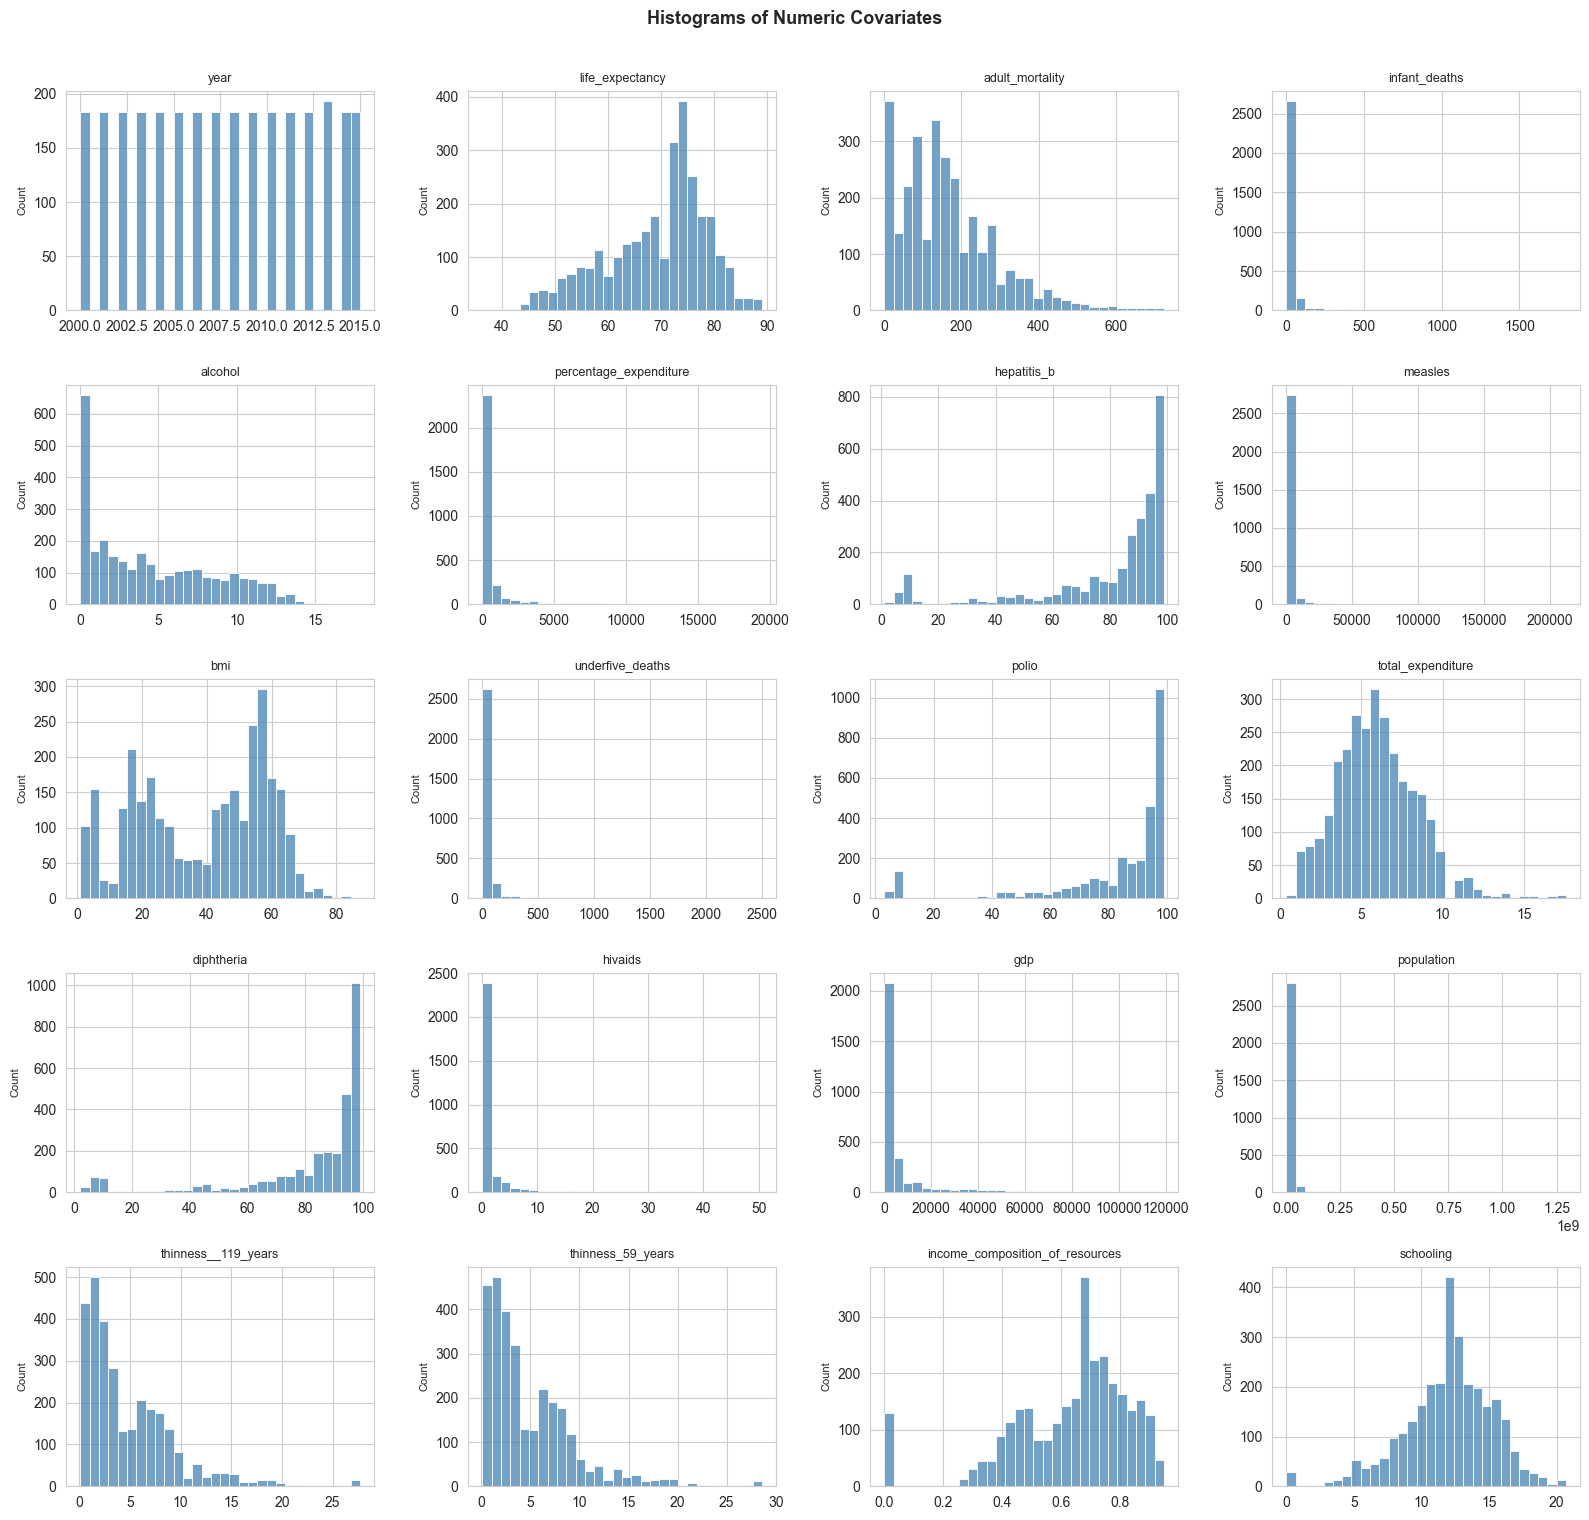

In [11]:
fig, axes = plt.subplots(5, 4, figsize=(16, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), ax=axes[i], bins=30, color="steelblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count", fontsize=8)

# Hide any unused axes
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histograms of Numeric Covariates", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

We therefore use the following chunk to take the log of these variables.

In [12]:
skewed = ['infant_deaths', 'percentage_expenditure', 'measles', 'underfive_deaths', 'hivaids', 'gdp', 'population']

for col in skewed:
    if col in df.columns:
        df[col] = np.log1p(df[col].clip(lower=0))

## 3. Exploratory Data Analysis

### 3.1 Summary Statistics

We proceed to our data exploration and start by producing tables of summary statistics.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.1 Summary Statistics

Produce a table of the key summary statistics (mean, standard deviation, minimum, LQ, median, UQ, max, range, skew and kurtosis) for all numerical covariates.  Provide a few comments on the results including observations about skewed covariates, potential outliers or other points of note.

---

In [13]:
desc = df.describe().T

desc['range'] = desc['max'] - desc['min']
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()

summary_table = desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'skew', 'kurtosis']]
summary_table.columns = ['Mean', 'Std Dev', 'Min', 'LQ', 'Median', 'UQ', 'Max', 'Range', 'Skew', 'Kurtosis']

display(summary_table.round(2))

,Mean,Std Dev,Min,LQ,Median,UQ,Max,Range,Skew,Kurtosis
year,2007.52,4.61,2000.00,2004.00,2008.00,2012.00,2015.00,15.00,-0.01,-1.21
life_expectancy,69.23,9.51,36.30,63.20,72.10,75.60,89.00,52.70,-0.64,-0.22
adult_mortality,164.73,124.09,1.00,74.00,144.00,227.00,723.00,722.00,1.18,1.77
infant_deaths,1.77,1.66,0.00,0.00,1.39,3.14,7.50,7.50,0.70,-0.33
alcohol,4.61,4.03,0.01,0.92,3.77,7.68,17.87,17.86,0.59,-0.80
percentage_expenditure,3.99,2.73,0.00,1.74,4.19,6.09,9.88,9.88,-0.08,-1.02
hepatitis_b,80.10,24.55,1.00,75.00,91.00,96.00,99.00,98.00,-1.83,2.47
measles,3.36,3.26,0.00,0.00,2.89,5.89,12.27,12.27,0.56,-0.88
bmi,38.38,19.94,1.00,19.40,43.50,56.10,87.30,86.30,-0.23,-1.27
underfive_deaths,1.94,1.78,0.00,0.00,1.61,3.37,7.82,7.82,0.65,-0.51


Observations about skewed covariates
Right Skew below -2
diphtheria
polio
hivaids

Potential Outliers
adult_morality high
infant_deaths high
alcohal high
heptitis_b low
polio low
diphtheria low
thinnness_199_years high
thinness_59_years high

This data has very diffrent scales based on the row

---

### 3.2 Univariate Analysis

First, lets consider our categorical covariate `status`. 

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.2 Countplot of `status`

Produce a countplot of the covariate `status` to visualize the proportion of developing countries against developed countries.  Comment on your resulting plot.

---

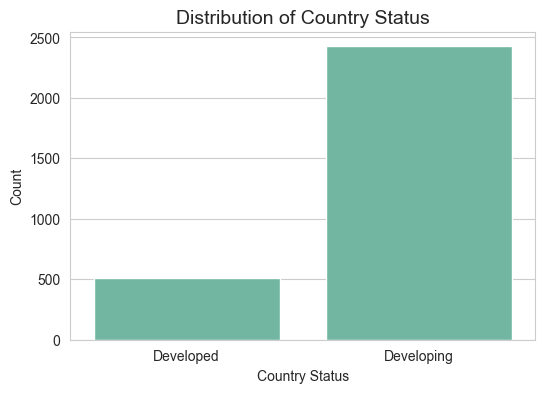

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='status')

plt.title('Distribution of Country Status', fontsize=14)
plt.xlabel('Country Status')
plt.ylabel('Count')

plt.show()

There are much more developing countries compared to Developed countries. This does not work well with using the average value for missing data sets in devloping countries and skews our data evern more

---

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.3 Histogram Multiplot

Produce a multiplot with 5 rows and 4 columns showing estimates for the distributions for the 20 numerical covariates.  Discuss your findings and the distributions of our transformed covariates.

---

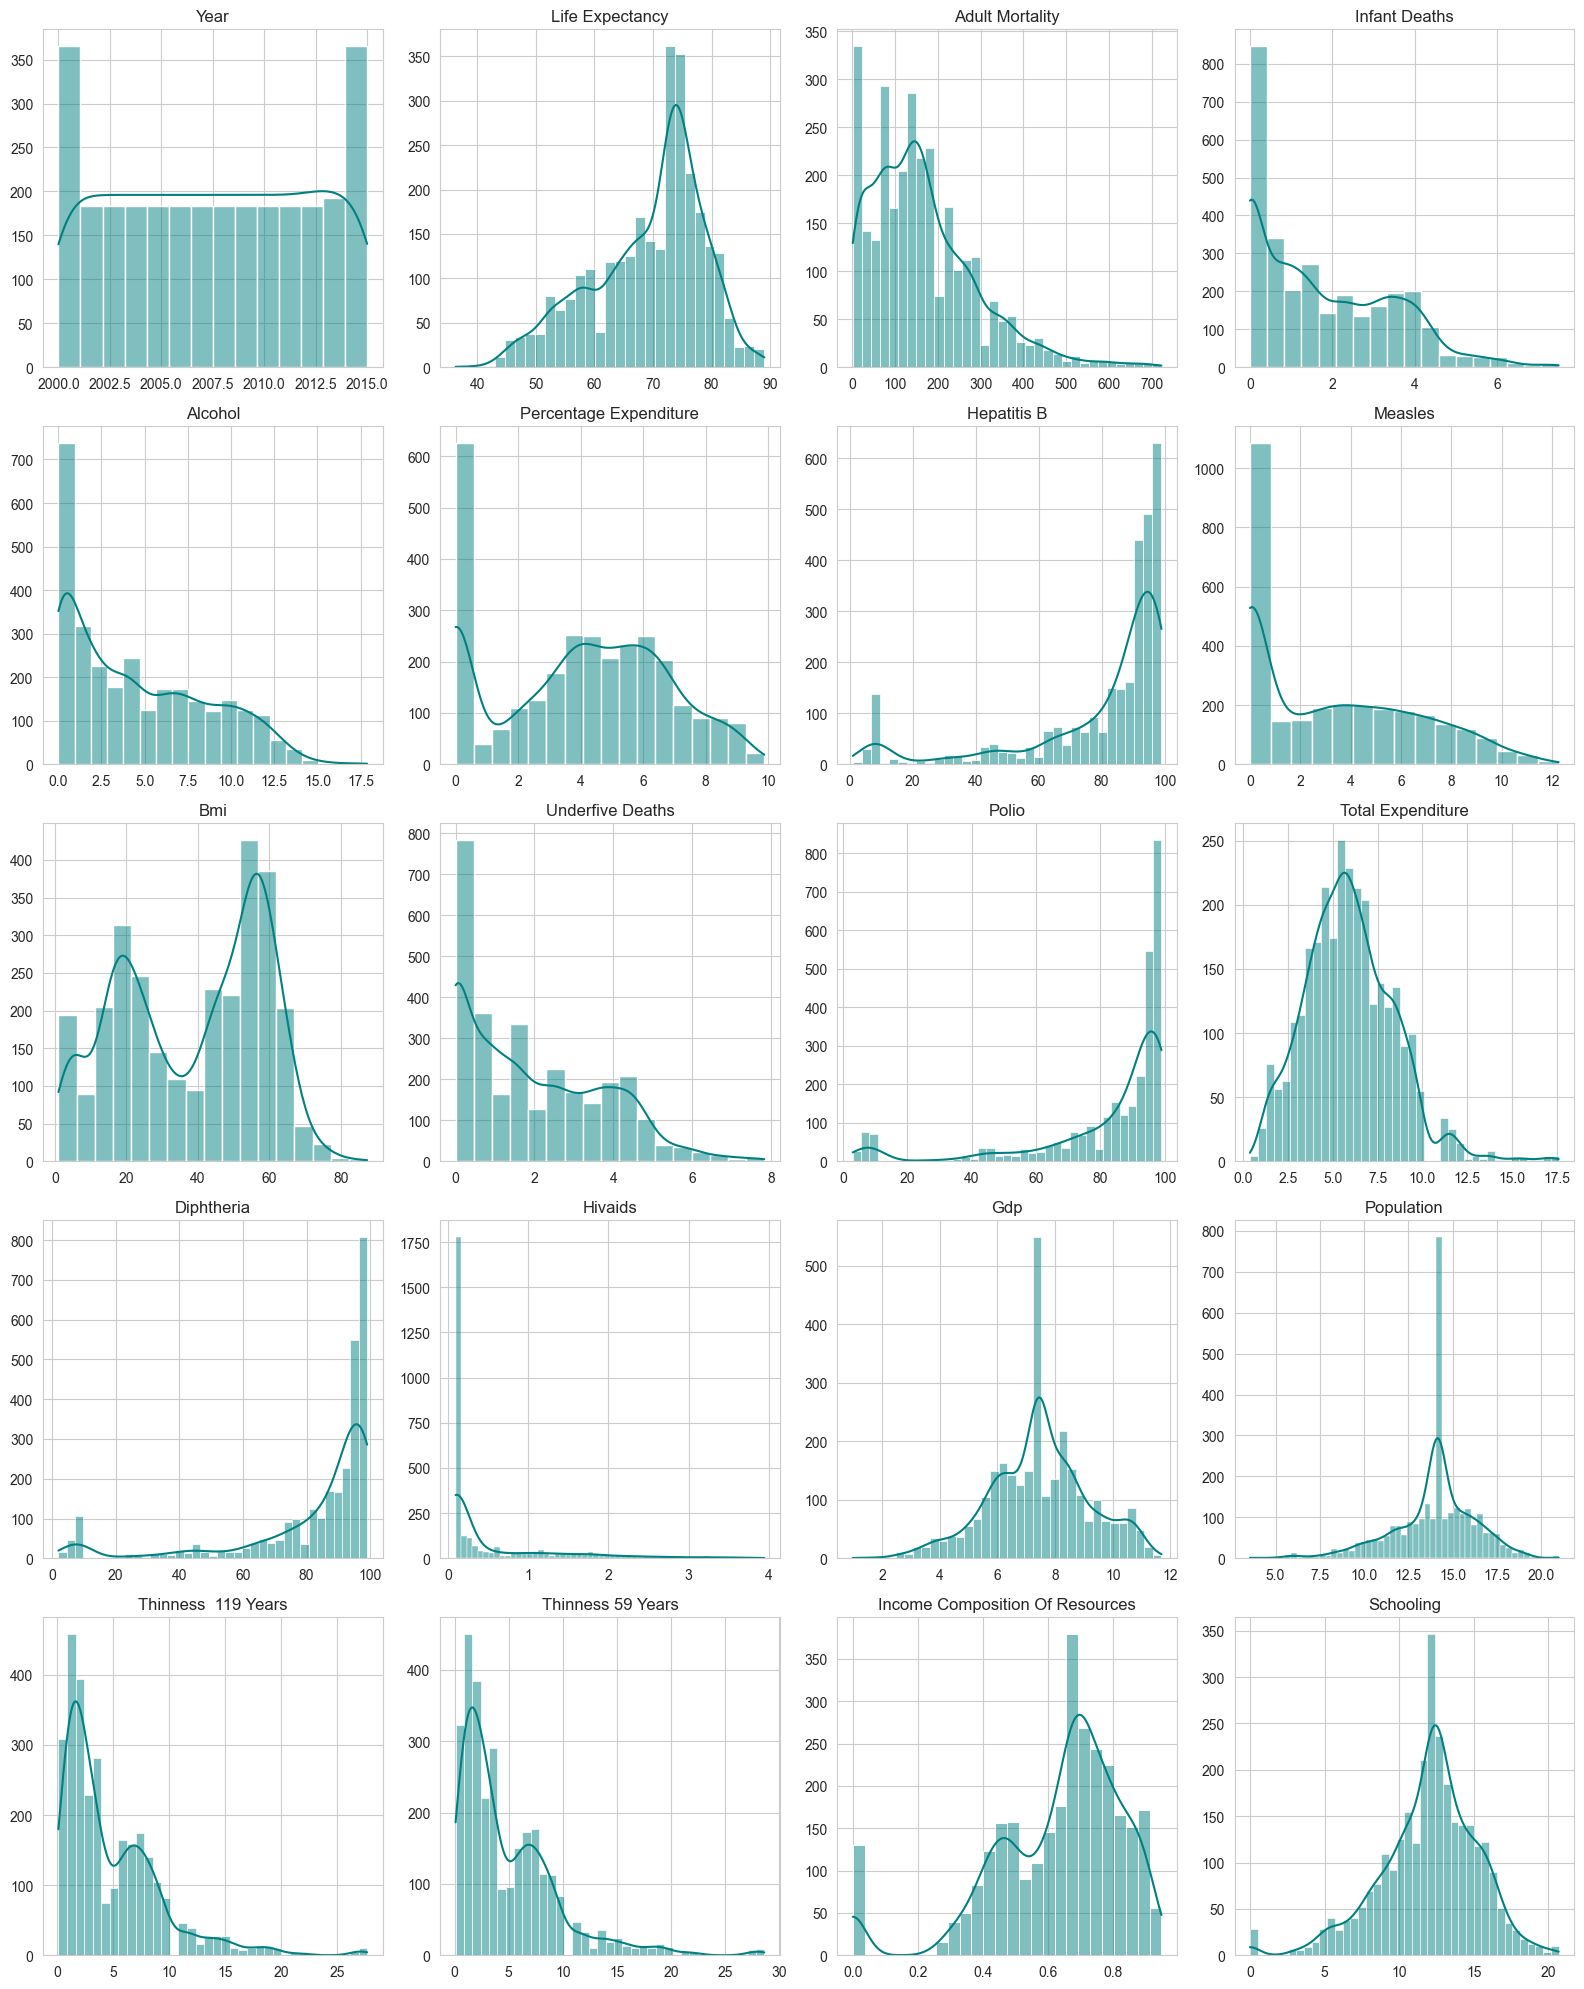

In [15]:
fig, axes = plt.subplots(5, 4, figsize=(16, 20))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

The graphs GDP, total expenditure, population, life expectancy schooling all seem approzimately normal. 
Both thinness plots, income composition of resources and bmi show a bimodial graph
Right skew shown by the thiness plots, HIVaids, measeles, underfive deaths, adult mortality and infant deaths
Left skew shown by diphtheria, polio, hep b, and life expectancy

---

### 3.3 Bivariate Analysis

We begin our bivariate analysis by looking at the relationship between our response and the categorical variable `status`.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.4 Violin and Grouped Histogram Plot

Produce a multiplot containing the following:

1. A violin plot of `life_expectancy` against `status`; and
2. A histogram of `life_expectancy` grouped by `status`.

Comment on whether you see evidence of a significant difference in the distribution of `life_expectancy` between developed and developing countries.

---

/var/folders/l6/dr99v_w91snds4bys0r_6qhw0000gn/T/ipykernel_19480/3466844165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='status', y='life_expectancy', ax=axes[0], palette='muted')


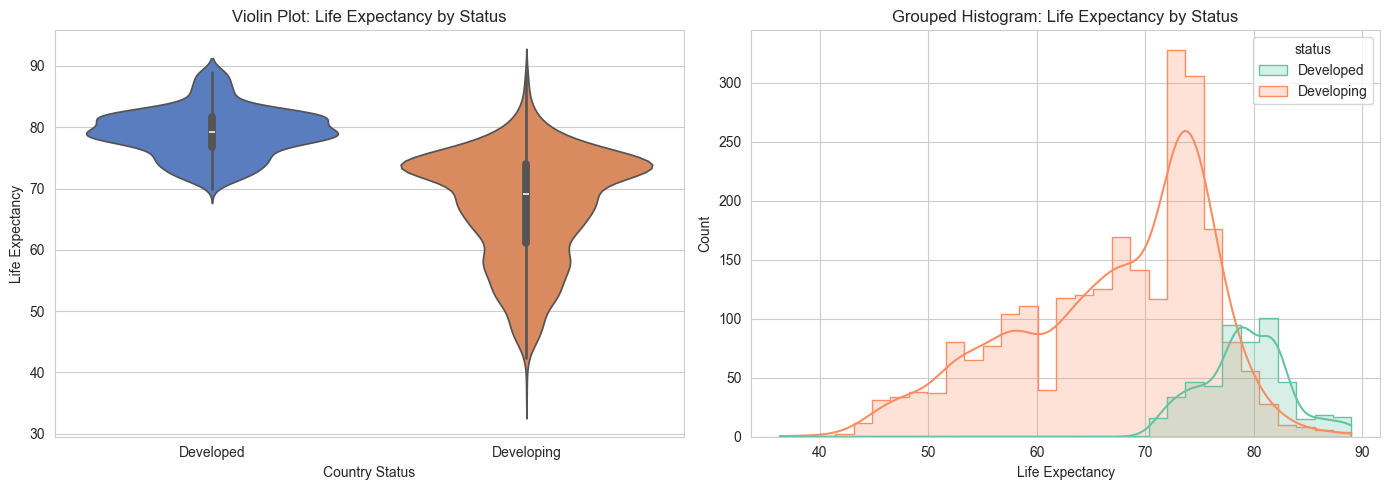

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. A violin plot of `life_expectancy` against `status`;
sns.violinplot(data=df, x='status', y='life_expectancy', ax=axes[0], palette='muted')
axes[0].set_title('Violin Plot: Life Expectancy by Status')
axes[0].set_xlabel('Country Status')
axes[0].set_ylabel('Life Expectancy')

# 2. A histogram of `life_expectancy` grouped by `status`.
sns.histplot(data=df, x='life_expectancy', hue='status', kde=True, ax=axes[1], element="step", common_norm=False)
axes[1].set_title('Grouped Histogram: Life Expectancy by Status')
axes[1].set_xlabel('Life Expectancy')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Life expectance in developed countries seems to be higher as well as has a smaller range. Developing countries have a lower avegare expectancy and also have a much larger spread of expectancy with the bell curve showing a large left skew.

---

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.5 Correlation Heat Map

Produce a correlation heat map of the numerical variables in the dataset.  Write some code to return the covariates with the strongest correlations.  Comment on the strongest positive and negative correlations you observe.  

---

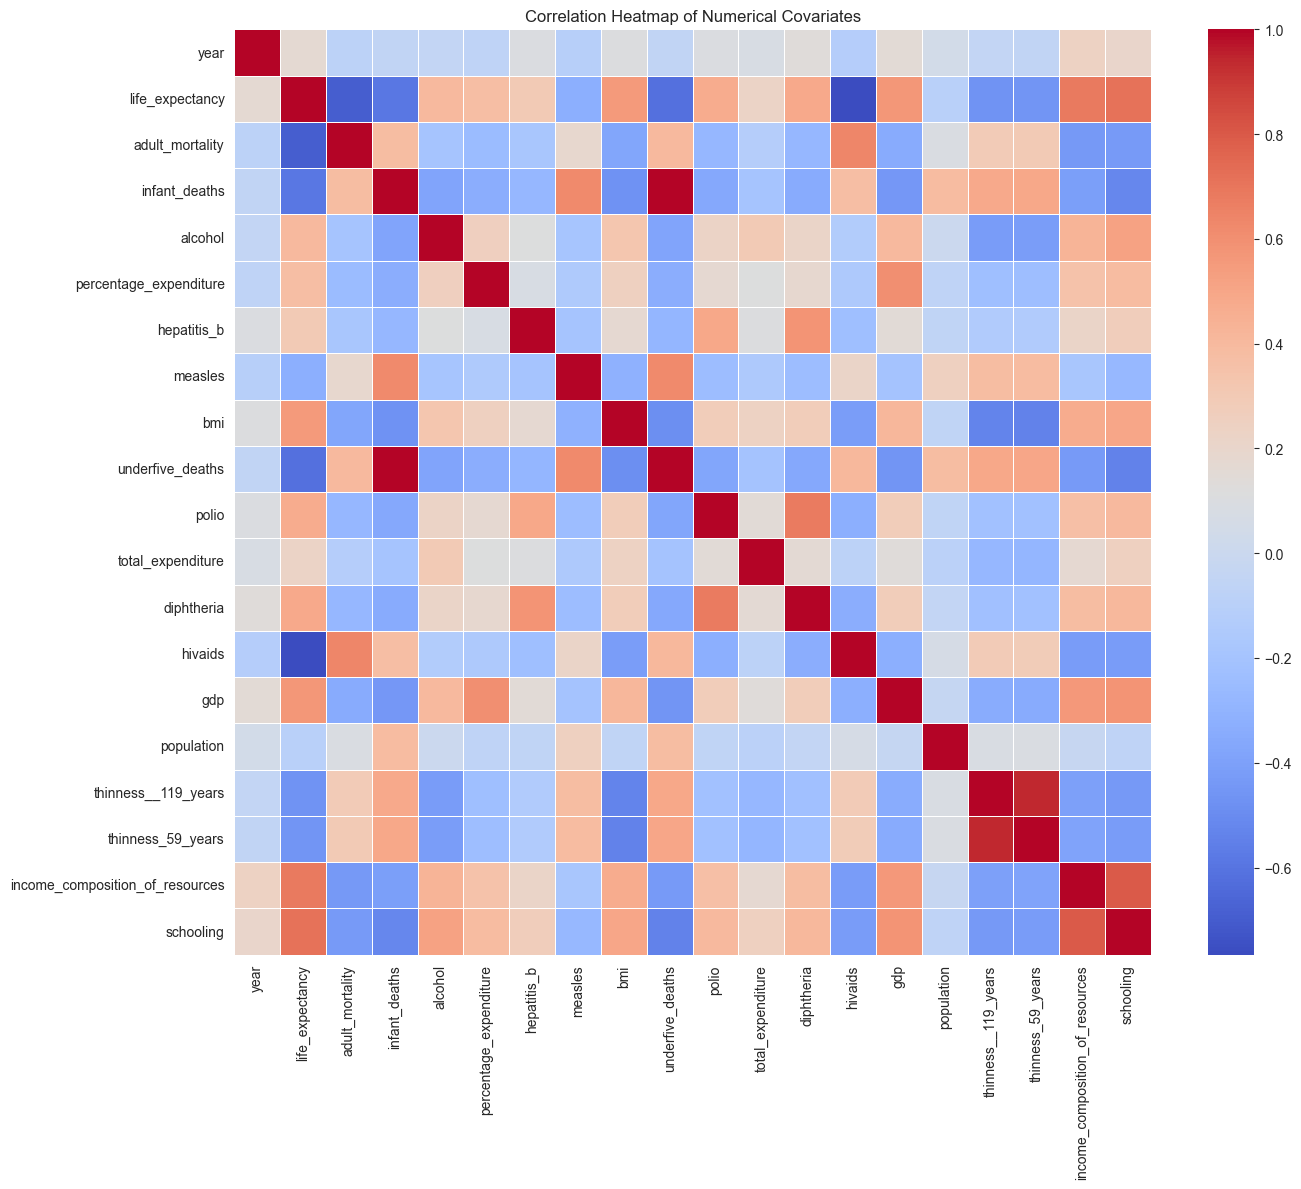

Top 5 Positive Correlations:
underfive_deaths                 infant_deaths                      0.996315
thinness_59_years                thinness__119_years                0.939187
schooling                        income_composition_of_resources    0.795383
                                 life_expectancy                    0.713054
income_composition_of_resources  life_expectancy                    0.688662
dtype: float64

Top 5 Negative Correlations:
hivaids           life_expectancy    -0.766335
adult_mortality   life_expectancy    -0.696390
underfive_deaths  life_expectancy    -0.621177
infant_deaths     life_expectancy    -0.592058
schooling         underfive_deaths   -0.541438
dtype: float64


In [18]:
# correlation heat map
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Covariates')
plt.tight_layout()
plt.show()

# strongest correlations 
corr_matrix = df.corr(numeric_only=True)
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).unstack().dropna()

print("Top 5 Positive Correlations:")
print(corr_pairs.sort_values(ascending=False).head(5))

print("\nTop 5 Negative Correlations:")
print(corr_pairs.sort_values(ascending=True).head(5))

The strongest positive correlation is underfive deaths and infant deaths meaning that almost all under five deaths can be predicted by infant deaths
The strongest negative coorelation is hivaids and life_expectancy as hivaids coorelated to a lower life expectancy

---

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.6 Scatter Multiplots

Produce a multiplot of 4 scatter plots each showing the relationship between `life_expectancy` and the 4 covariates with the highest correlation, with points grouped by `status`.  Note any relationships you see or any strange artifacts of our data preparation / inclusion of multiple years of data.

---

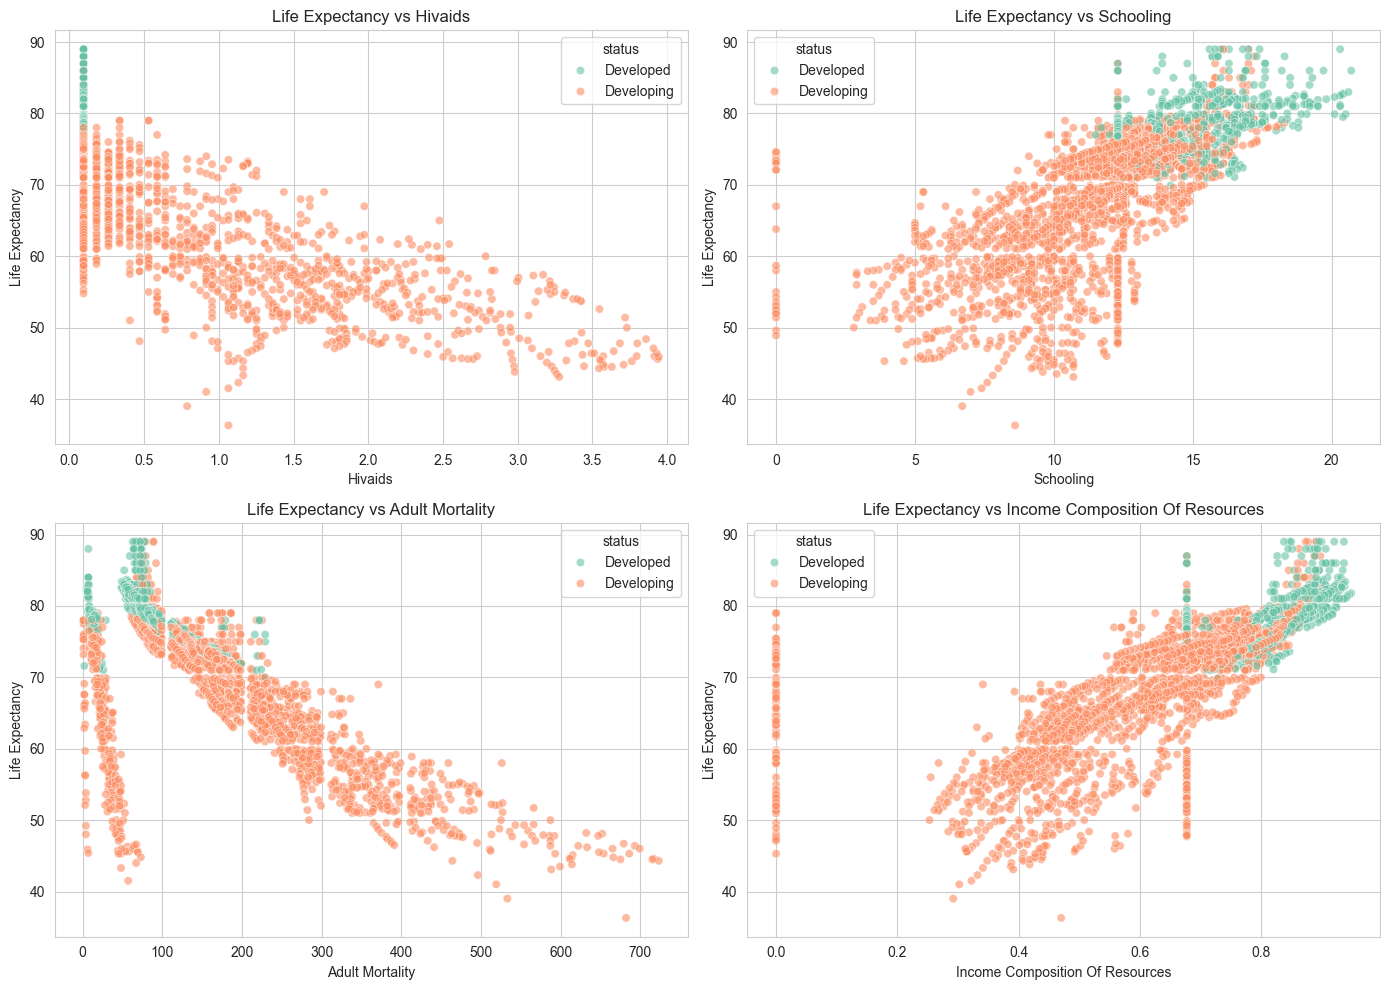

In [19]:
top_4_features = df.corr(numeric_only=True)['life_expectancy'].abs().sort_values(ascending=False).drop('life_expectancy').head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_4_features):
    sns.scatterplot(data=df, x=feature, y='life_expectancy', hue='status', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Life Expectancy vs {feature.replace("_", " ").title()}')
    axes[i].set_xlabel(feature.replace("_", " ").title())
    axes[i].set_ylabel('Life Expectancy')

plt.tight_layout()
plt.show()

For developed countires life expectancy isn't too affected by hivaids comapred to that on developing countires
Schooling genarally increases life expectancy and is higher for developed countries, same pattern is show for income composition of resources
For adult mortality the graph shows two lines / stripes which is particularly odd. 

these graphs overall show large diffreences based on status and may need to be grouped by statu for data analysis purposes
stripes occur because the dataset includes multiple years of data for the same countries, observations for the same country are not truly independent

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.7 Life Expectancy Over Time

Make a time series plot of life expectancy over the years grouped by `status`.  Are things moving in the right direction?

---

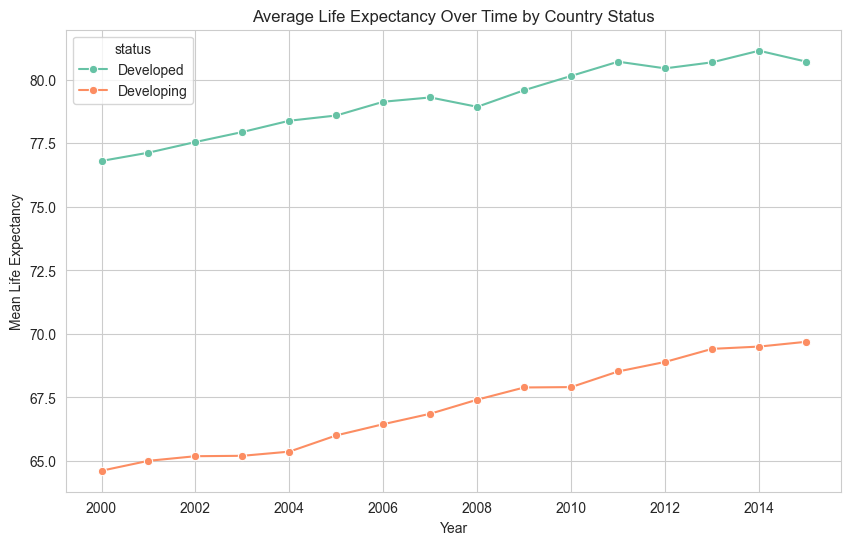

In [20]:
df_trend = df.groupby(['year', 'status'])['life_expectancy'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_trend, x='year', y='life_expectancy', hue='status', marker='o')

plt.title('Average Life Expectancy Over Time by Country Status')
plt.xlabel('Year')
plt.ylabel('Mean Life Expectancy')
plt.grid(True)
plt.show()

Positive trajectory for both developing and developed so yes things are moving in the right direction

---

## 4. Modelling

### 4.1. Simple Linear Regression

Let's start by fitting a simple linear regression model.  From our exploratory data analysis, we saw that life expectancy is positively correlated with several variables.  We will start with a simple model and then build upon it.

The covariate with the strongest correlation is `hivaids` thus we decide to use this as the sole covariate in our model.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q4.1 SLR

Fit a SLR of `life_expectancy` against `hivaids`.  Print the model summary table and comment on the results. What proportion of the variance in life expectancy is explained by the model?

---

In [ ]:
X = sm.add_constant(df['hivaids'])
y = df['life_expectancy']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     4178.
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        15:10:05   Log-Likelihood:                -9485.4
No. Observations:                2938   AIC:                         1.897e+04
Df Residuals:                    2936   BIC:                         1.899e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         74.0905      0.135    546.930      0.0

58.7% of model variation in life expectancy is explained by the model

The Prob(Omnibus) is still 0 indicating residuals are not perfectly normally distributed.
MLR would be better at explaining the model

---

### 4.2 Multiple Linear Regression

This is an excellent start but lets make things more interesting.  Lets fit a multiple linear regression model using several covariates including a dummy variable for the categorical `status`.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q4.2 MLR 

In this question fit multiple linear regression models with the following covariates:

1. `hivaids`, `gdp`, `underfive_deaths`, `infant_deaths`, `percentage_expenditure`, `measles` and `population`.
2. `hivaids`, `schooling`, `adult_mortality`, `income_composition_of_resources` and `status`.  
3. Your personal selection.

For each, print the model summary table and comment on the results.  Which model performed the best?

---

In [25]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
for col in numeric_cols:
    df[col] = df.groupby('country')[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

# Log transform
skewed_cols = ['hivaids', 'gdp', 'underfive_deaths', 'infant_deaths', 'percentage_expenditure', 'measles', 'population']
for col in skewed_cols:
    df[col] = np.log(df[col] + 1)

y = df['life_expectancy']

# Model 1
X1_cols = ['hivaids', 'gdp', 'underfive_deaths', 'infant_deaths', 'percentage_expenditure', 'measles', 'population']
X1 = sm.add_constant(df[X1_cols])
model1 = sm.OLS(y, X1).fit()

# Model 2
X2_cols = ['hivaids', 'schooling', 'adult_mortality', 'income_composition_of_resources', 'status_developing']
X2 = sm.add_constant(df[X2_cols])
model2 = sm.OLS(y, X2).fit()

# Model 3 (combining strong predictors)
X3_cols = ['schooling', 'adult_mortality', 'income_composition_of_resources', 'bmi', 'total_expenditure', 'status_developing', 'hivaids']
X3 = sm.add_constant(df[X3_cols])
model3 = sm.OLS(y, X3).fit()

print("MODEL 1 SUMMARY")
print(model1.summary())
print("\nMODEL 2 SUMMARY")
print(model2.summary())
print("\nMODEL 3 SUMMARY")
print(model3.summary())

MODEL 1 SUMMARY
                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     1189.
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        15:19:26   Log-Likelihood:                -8808.5
No. Observations:                2938   AIC:                         1.763e+04
Df Residuals:                    2930   BIC:                         1.768e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const       

In all models, status_developing remained a highly significant

Model 1
this model performs reasonably well, capturing 74% of the variance. infant_deaths and underfive_deaths are both included. Given their 99% correlation this creates redundancy

Model 2
By switching to more direct predictors of development
schooling, income_composition_of_resources, and status, 
the model fit improves significantly to 82.4%

Model 3
This is the best-performing model at 82.9%. Includes bmi and total_expenditure in addition to the strong predictors from Model 2


---

## 5. Residual Analysis

Lets consider MLR model 2 from Section 4.2.  We will perform some residual analysis to examine the fit of our model and whether our model assumptions are met.



<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>


#### Q5.1 Residual Analysis

By copying and modifying the code from lecture, produce a multiplot which contains the following 4 residual analysis plots:

1. Residuals vs Fitted
2. Normal Q-Q
3. Scale-Location
4. Cook's Distance

**Note:** The Cook's distance threshold of 4/n is more typically used for smaller data sets and is too strict for large data sets.  Change this to a fixed threshold of 0.5.

Read online about how to read these plots and comment on what each tells us about our model and underlying assumptions.

---

<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
/var/folders/l6/dr99v_w91snds4bys0r_6qhw0000gn/T/ipykernel_19480/3684889873.py:16: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel('Fitted values $\hat{y}$')
/var/folders/l6/dr99v_w91snds4bys0r_6qhw0000gn/T/ipykernel_19480/3684889873.py:39: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel('Fitted values $\hat{y}$')
/Users/chloelopapa/Downloads/Python/PSTAT_100/.venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


Influential observations: []


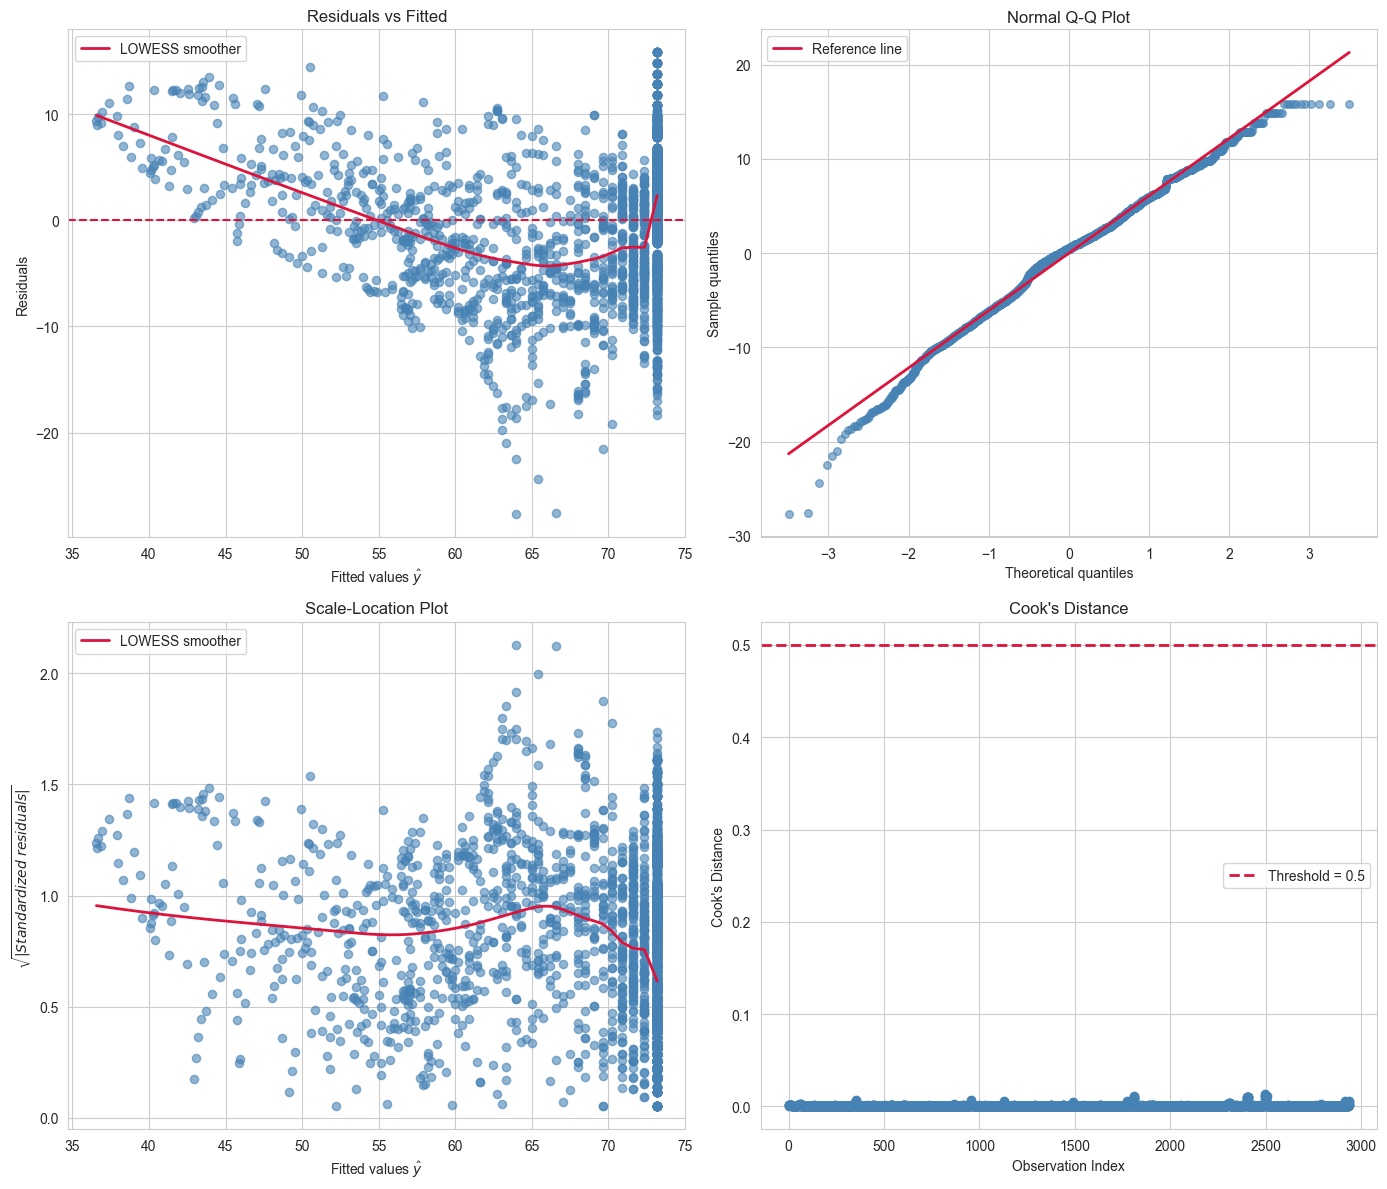

In [ ]:
fitted = model.fittedvalues
residuals = model.resid
resid_std = residuals / np.sqrt(np.sum(residuals**2) / (len(residuals) - model.df_model - 1))
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 0.5

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax = axes[0, 0]
ax.scatter(fitted, residuals, alpha=0.6, color='steelblue', s=35)
ax.axhline(0, color='crimson',linestyle='--',lw=1.5) 
lowess = sm.nonparametric.lowess(residuals, fitted, frac=0.5)

ax.plot(lowess[:, 0],lowess[:, 1],color='crimson',lw=2,label='LOWESS smoother')
ax.set_xlabel('Fitted values $\hat{y}$')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
ax.legend()


ax = axes[0, 1]
qq_result = probplot(residuals, dist='norm')
ax.scatter(qq_result[0][0],qq_result[0][1],alpha=0.6,color='steelblue',s=30)
ax.plot(qq_result[0][0],qq_result[1][1] + qq_result[1][0] * qq_result[0][0],color='crimson', lw=2, label='Reference line')

ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Normal Q-Q Plot')
ax.legend()


ax = axes[1, 0]
sqrt_abs = np.sqrt(np.abs(resid_std))
ax.scatter(fitted,sqrt_abs,alpha=0.6,color='steelblue',s=35)
lowess = sm.nonparametric.lowess(sqrt_abs, fitted, frac=0.5)
ax.plot(lowess[:, 0],lowess[:, 1],color='crimson',lw=2,label='LOWESS smoother')

ax.set_xlabel('Fitted values $\hat{y}$')
ax.set_ylabel(r'$\sqrt{|Standardized\ residuals|}$')
ax.set_title('Scale-Location Plot')
ax.legend()


ax = axes[1, 1]
markerline, stemlines, baseline = ax.stem(range(len(cooks_d)),cooks_d,linefmt='steelblue',markerfmt='o',basefmt=' ')

ax.axhline(threshold,color='crimson',linestyle='--',lw=2,label=f'Threshold = {threshold}')

flagged = np.where(cooks_d > threshold)[0]

print("Influential observations:", flagged)

ax.set_xlabel('Observation Index')
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance")
ax.legend()


plt.tight_layout()
plt.show()

Residuals vs. Fitted Linearity and Homoscedasticity, 
points centered around the horizontal line yet have a funnel shape meaining the variance is not constant, which violates the assumptions of OLS

Normal Q-Q Normality of errors
residuals should track closely along the dashed line. Points deviate slightly at the ends so p-values and confidence intervals might be slightly inaccurate

Scale-Location Homoscedasticity 
Points are not equally spread points, confirms non-constant variance 

Cook’s Distance Influential points (High Leverage)
With threshold of .5, any point above the red line is an observation that significantly changes the model results. No such points in my model

---

## Submission

1. Save file to confirm all changes are on disk
2. Run *Kernel > Restart & Run All* to execute all code from top to bottom
3. Save file again to write any new output to disk
4. Export your notebook as a pdf (either through latex or as html before saving as a pdf).
5. Submit your pdf to Canvas.